<a href="https://colab.research.google.com/github/FareedaAbdelaal/ML-55-9988/blob/main/ML_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import urllib.request
import zipfile
import os

# Download Dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
zip_path = "bank-additional.zip"

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

In [2]:
# Load dataset


df = pd.read_csv("bank-additional/bank-additional-full.csv", sep=';')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Features types

numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numeric Features:\n", numeric_cols)
print("\nCategorical Features:\n", categorical_cols)

Numeric Features:
 Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

Categorical Features:
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')


In [4]:
# Numeric summary statistics
df[numeric_cols].describe()
# Skewness
df[numeric_cols].skew()

,0
age,0.784697
duration,3.263141
campaign,4.762507
pdays,-4.922190
previous,3.832042
emp.var.rate,-0.724096
cons.price.idx,-0.230888
cons.conf.idx,0.303180
euribor3m,-0.709188
nr.employed,-1.044262


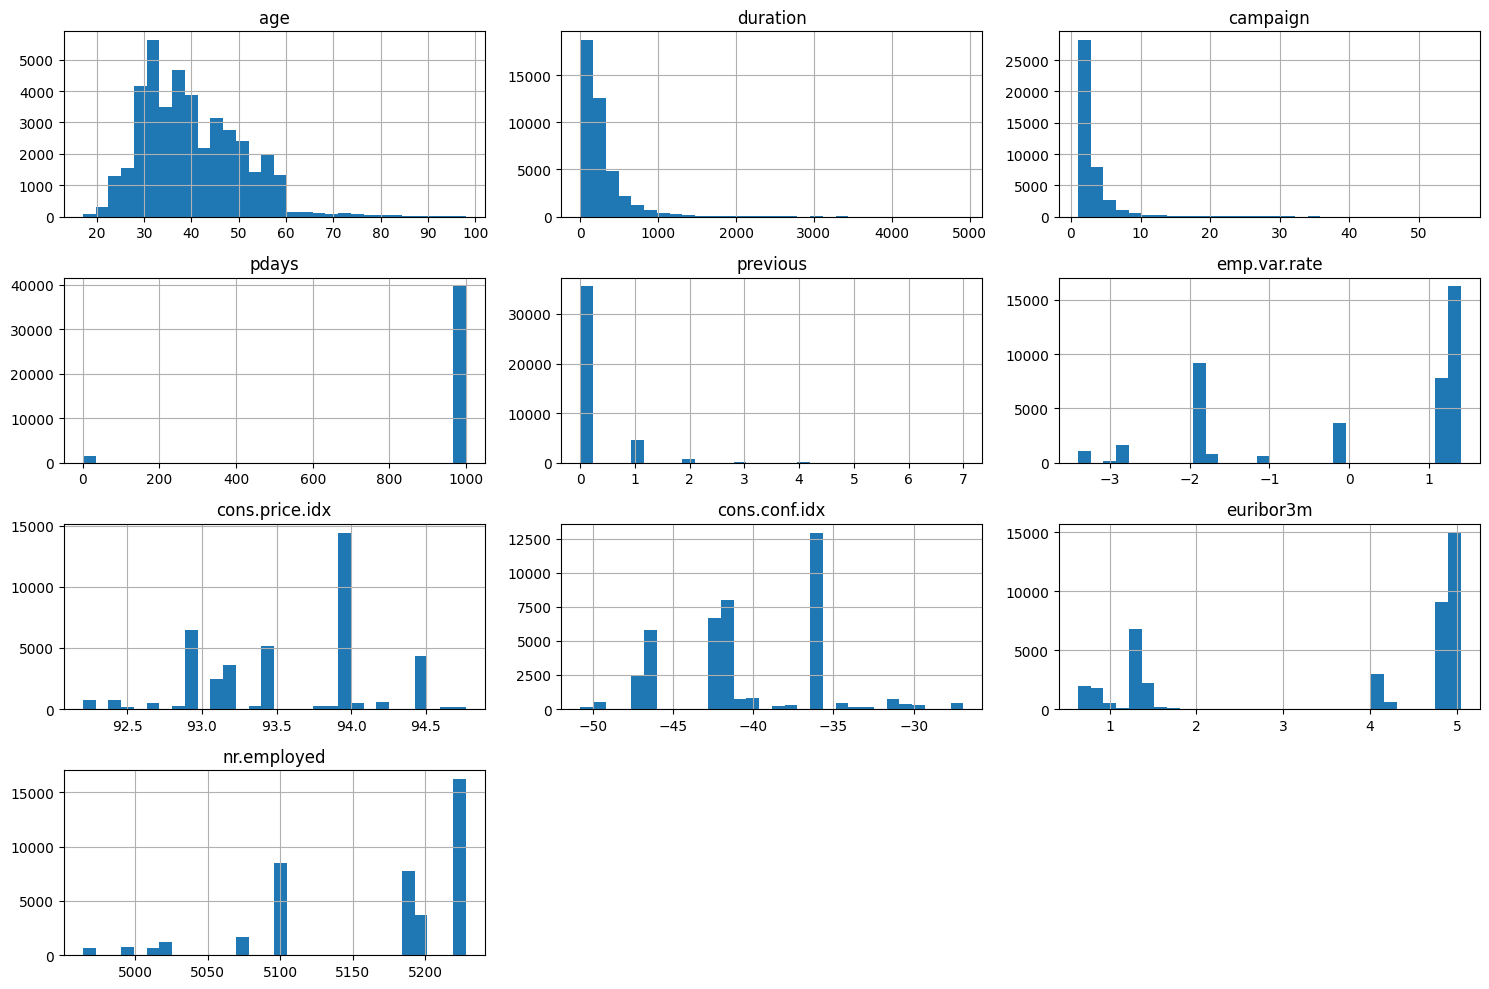

In [5]:
# Histograms

df[numeric_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

In [6]:
# Value counts

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())


 job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

 marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

 education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

 default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

 housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

 loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

 contact
con

In [7]:
# Missing value check

df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


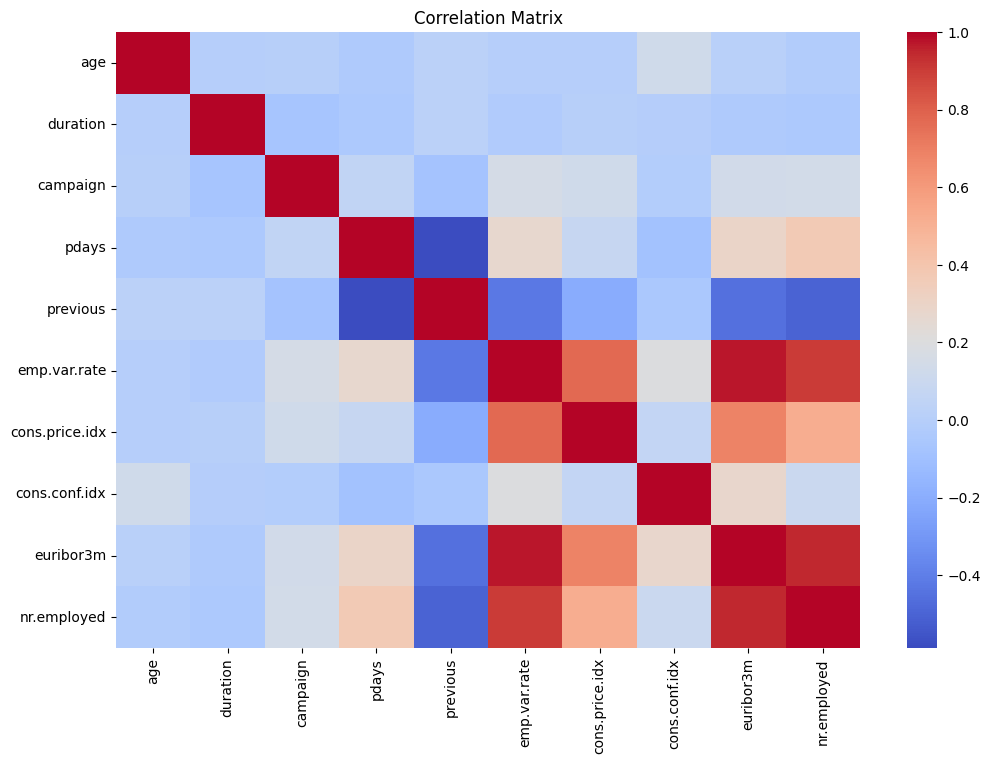

In [8]:
# Correlation Matrix

plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

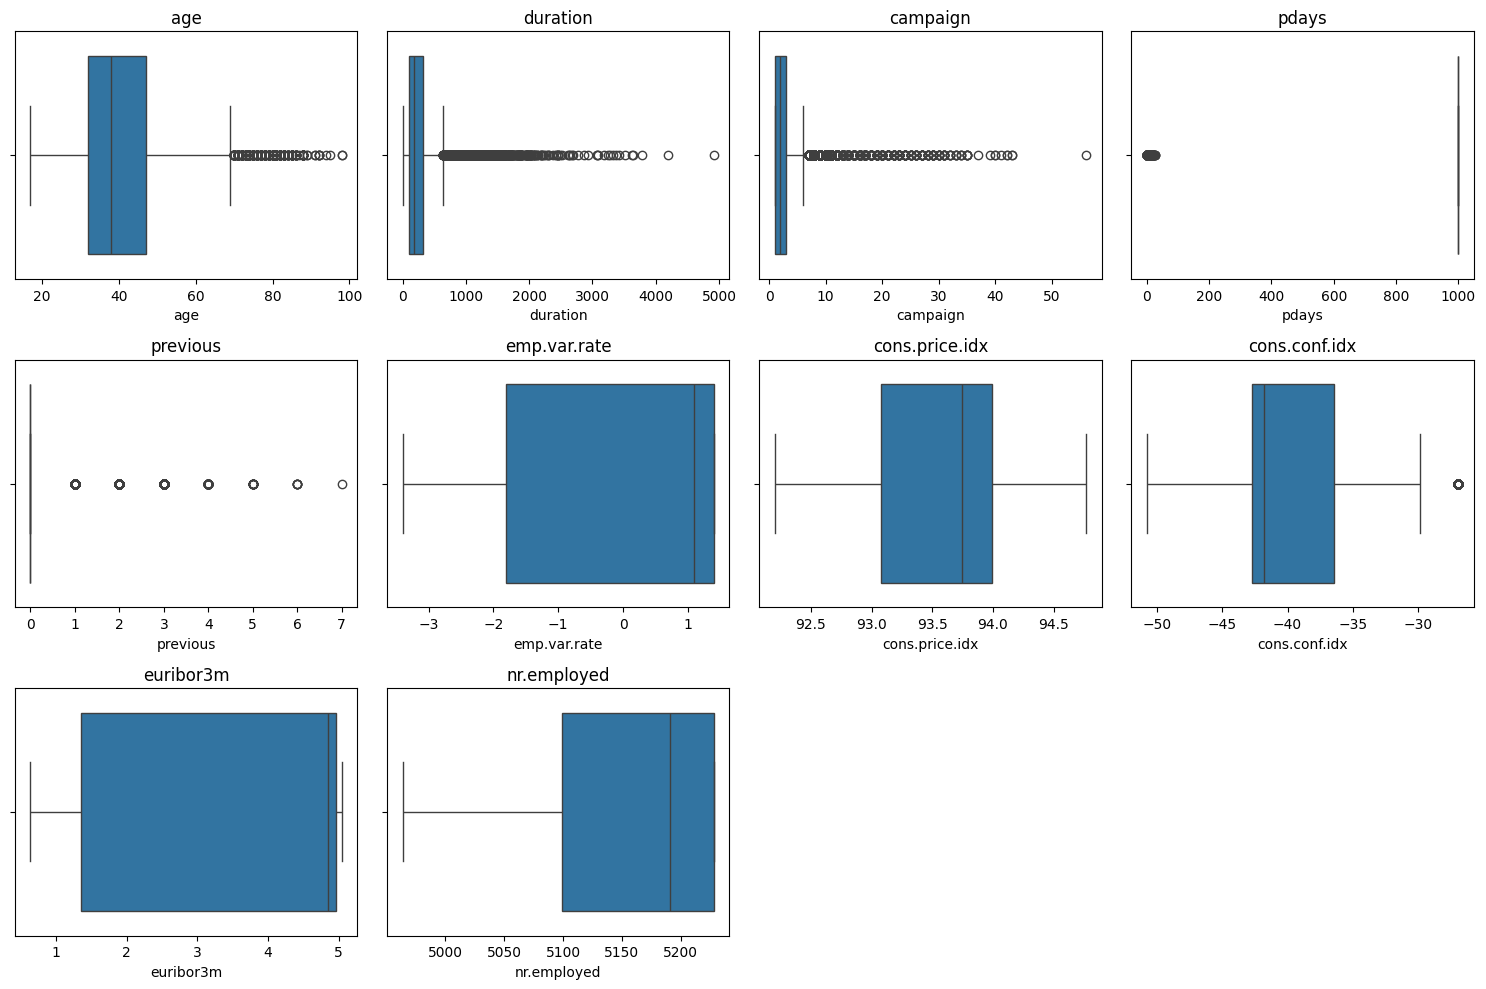

In [9]:
# Boxplots

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3,4,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [10]:
# DCleaning the data
df_clean = df.drop(['y','duration'], axis=1)
df_clean.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0


In [11]:
#Encoding
df_encoded = pd.get_dummies(df_clean, drop_first=True)
df_encoded.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False


In [12]:
#Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)

df_scaled = pd.DataFrame(scaled_data, columns=df_encoded.columns)

print("Final dataset shape:", df_scaled.shape)
print("Missing values:", df_scaled.isnull().sum().sum())

Final dataset shape: (41188, 52)
Missing values: 0


In [13]:
# K means
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
clusters = kmeans.fit_predict(df_scaled)

df_scaled['cluster'] = clusters

df_scaled['cluster'].value_counts()

,count
cluster,
2,24120
1,15548
0,1520


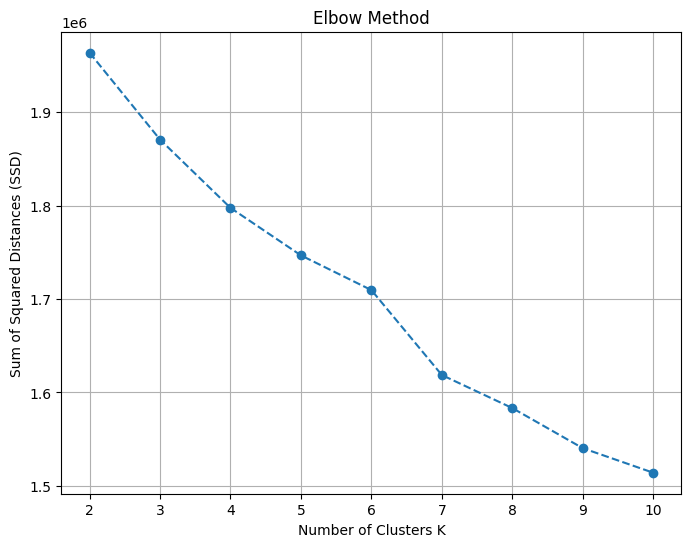

In [14]:
# Elbow method
ssd = []
K_range = range(2,11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(df_scaled.drop('cluster', axis=1))
    ssd.append(km.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K_range, ssd, 'o--')
plt.xlabel("Number of Clusters K")
plt.ylabel("Sum of Squared Distances (SSD)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

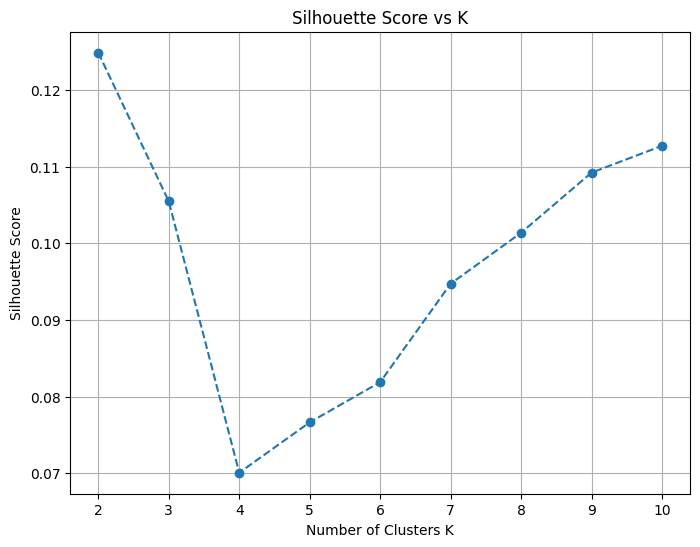

In [15]:
# Silhouette scores

sil_scores = []

for k in range(2,11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(df_scaled.drop('cluster', axis=1))
    score = silhouette_score(df_scaled.drop('cluster', axis=1), labels)
    sil_scores.append(score)

plt.figure(figsize=(8,6))
plt.plot(range(2,11), sil_scores, 'o--')
plt.xlabel("Number of Clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.grid(True)
plt.show()

In [16]:
# Interpretation of the cluster
df_with_clusters = df_clean.copy()
df_with_clusters['cluster'] = clusters

cluster_profile = df_with_clusters.groupby('cluster').mean(numeric_only=True)
cluster_profile

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
cluster,,,,,,,,,
0,41.828947,1.823684,9.280921,1.671053,-2.093750,93.345098,-38.339671,0.985632,5029.065592
1,39.684847,2.073193,999.000000,0.294829,-1.588590,93.036248,-42.912876,1.861926,5104.573167
2,40.128980,2.933167,999.000000,0.000000,1.295796,93.937908,-39.085216,4.921490,5215.994685


### **SUMMARY: **

The Bank Marketing dataset contains over 41,000 customer records with a mix of personal information, campaign details, and economic indicators. It includes both numeric and categorical features, so the categorical variables had to be encoded before applying K-Means. Most numeric features like campaign, previous, and especially duration were heavily right skewed and had some clear outliers. The economic variables such as interest rate and employment indicators were strongly correlated with each other, which suggests they move together over time. There were no actual missing NaN values in the dataset, but several columns contained "unknown" values, which we kept as separate categories. Since this is an unsupervised learning task, we removed the target variable y and also dropped duration because it could leak information and is not realistic for clustering before a call happens. After encoding the categorical features and scaling all variables to make them comparable, we applied KMeans clustering. Based on the Elbow Method and Silhouette Score, around three clusters seemed to be a reasonable choice. The clusters were not perfectly separated, but they still provided meaningful customer groupings that could be useful for segmentation.